# ИАД

## Домашнее задание 4. Трансформеры.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этой домашней работе вам предстоит добавить к BERT'у декодерную часть и решить задачу написания tl;dr для текстов новостей на русском языке.

Дополнительно к этому на отличную оценку потребуется реализовать менее жадную стратегию выбора следующего токена для генерации.

In [ ]:
!pip install transformers datasets evaluate

In [1]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, BertModel, BertTokenizer
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import clear_output

Зафиксируем различные сиды.

In [2]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    g = torch.Generator()
    g.manual_seed(seed)
    return g

g = set_global_seed(42)

## Подготовка данных (0.5 балла)

Мы воспользуемся датасетом с 🤗 Ильи Гусева "gazeta". Он представляет собой пары (полный текст новости -- его саммари).

Более подробно про датасет можно прочитать [здесь](https://huggingface.co/datasets/IlyaGusev/gazeta)



In [3]:
# Загрузим данные с попощью библиотеки библиотеки datasets
# Вы вольны взять меньше или больше данных, но что-то около адекватное получается обычно только на >=10%

from datasets import load_dataset

dataset = load_dataset("IlyaGusev/gazeta", split="train[:15%]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
dataset

Dataset({
    features: ['text', 'summary', 'title', 'date', 'url'],
    num_rows: 9145
})

Вы должны помнить, что тексты перед подачей в модель необходимо **токенизировать**.

Добавьте паддинг до `max_length=512` для обучающих данных, а также до `max_length=128` для меток.

Используйте обрезку текстов, длина которых в токенах превышает `max_length`

In [5]:
# Подготовим данные для модели Bert

model_name = "deepvk/bert-base-uncased"  # Указание модели BERT

tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess(examples, use_padding=True):
    model_inputs = tokenizer(
        examples['text'],
        max_length=512,
        padding="max_length" if use_padding else False,
        truncation=True
    )

    labels = tokenizer(
        text_target=examples['summary'],
        max_length=128,
        padding="max_length" if use_padding else False,
        truncation=True
    )

    model_inputs['labels'] = labels['input_ids']

    return model_inputs

In [6]:
tokenized_dataset = dataset.map(preprocess, batched=False)
tokenized_dataset.set_format("torch")

In [7]:
from torch.utils.data import DataLoader

tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.15)

train_dataset = tokenized_dataset['train']
eval_dataset = tokenized_dataset['test']

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
eval_dataloader = DataLoader(eval_dataset, batch_size=8, shuffle=False)

## Реализация Decoder-cети (3 балла)

В данном разделе вам необходимо **реализовать собственный декодер для генерации текста**.

Можете вдохновляться кодом с семинара. В инициализации весов стоит (но необязательно) вспомнить нюансы.

In [8]:
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer

# Класс кастомного декодера
class DecoderLayer(nn.Module):
    def __init__(self, hidden_size, num_heads, dropout):
        super().__init__()

        # MultiheadAttention, смотрящий на сгенерированные токены декодера
        self.self_attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout
        )

        # MultiheadAttention, смотрящий на сгенерированные векторные представления
        # токенов энкодером
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout
        )

        # Feed-Forward (FFN)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size*4),
            nn.ReLU(),
            nn.Linear(hidden_size*4, hidden_size)
        )

        # LayerNorm и Dropout
        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.norm3 = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, tgt_mask=None):
        # Self-Attention
        x_residual = x
        x = x.transpose(0, 1)
        x, _ = self.self_attn(x, x, x, attn_mask=tgt_mask)
        x = x.transpose(0, 1)
        x = self.norm1(x_residual + self.dropout(x))

        # Encoder-Decoder Attention
        x_residual = x
        x = x.transpose(0, 1)
        memory_t = memory.transpose(0, 1)
        x, _ = self.cross_attn(x, memory_t, memory_t)
        x = x.transpose(0, 1)
        x = self.norm2(x_residual + self.dropout(x))

        # Feed Forward
        x_residual = x
        x = self.ffn(x)
        x = self.norm3(x_residual + self.dropout(x))

        return x

# Класс модели для суммаризации на основе BERT с кастомным декодером
class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size

        # Эмбеддинги для токенов на входе в декодер
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        # Декодерные слои
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(hidden_size, num_heads, dropout) for _ in range(num_decoder_layers)]
        )

        # Выходной слой: предсказываем следующий токен
        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.log_softmax = nn.LogSoftmax(dim=-1)

        # Инициализируем все веса, кроме BERT
        self.embedding.apply(self._init_weights)
        for layer in self.decoder_layers:
            layer.apply(self._init_weights)
        self.fc_out.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            # Инициализация линейных слоёв (Xavier/Glorot)
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Инициализация эмбеддингов нормальным распределением
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    # Функция для создания маски для предотвращения заглядывания вперед в декодере
    def generate_square_subsequent_mask(self, T):
        mask = (torch.triu(torch.ones(T, T)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = (
            encoder_outputs.last_hidden_state
        )  # Выходы BERT для использования в декодере

        # Эмбеддинги для входных токенов декодера
        x = self.embedding(decoder_input_ids)

        # Генирируем масиву для предотвращения заглядывания вперед в декодере
        tgt_mask = self.generate_square_subsequent_mask(x.size(1)).to(x.device)

        # Проходимся по всем слоям в декодере
        for layer in self.decoder_layers:
            x = layer(x, memory, tgt_mask=tgt_mask)

        # Далее линейный словй и возвращаем LogSoftmax
        output = self.fc_out(x)
        return self.log_softmax(output)

    def generate(self, input_ids, attention_mask, tokenizer, max_len=50):
        self.eval()
        with torch.no_grad():
            encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            memory = encoder_outputs.last_hidden_state
            batch_size = input_ids.size(0)

            decoder_input_ids = torch.full(
                (batch_size, 1),
                tokenizer.cls_token_id,
                dtype=torch.long,
                device=input_ids.device
            )

            finished = torch.zeros(batch_size, dtype=torch.bool, device=input_ids.device)

            for _ in range(max_len):
                x = self.embedding(decoder_input_ids)
                tgt_mask = self.generate_square_subsequent_mask(x.size(1)).to(x.device)

                for layer in self.decoder_layers:
                    x = layer(x, memory, tgt_mask)

                logits = self.fc_out(x)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)

                finished |= (next_token.squeeze(-1) == tokenizer.sep_token_id)

                decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=1)

                if finished.all():
                    break
        texts = []
        for seq in decoder_input_ids.tolist():
            tokens = []
            for token_id in seq:
                if token_id == tokenizer.sep_token_id:
                    break
                if token_id not in [tokenizer.cls_token_id, tokenizer.pad_token_id]:
                    tokens.append(token_id)

            text = tokenizer.decode(tokens, skip_special_tokens=True)
            texts.append(text)

        return texts

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Инициализируем нашу модель и посморим на ее архитектруру
model = BertSummarizer(bert_model_name=model_name)
model = model.to(device)
model

config.json:   0%|          | 0.00/669 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/455M [00:00<?, ?B/s]

BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(36000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [ ]:
# Посмотрим на генерацию без обучения

eval_data_sample = next(iter(eval_dataloader))
model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
)

['предупреждение ак ##вп coll произ флота дурак заметно голод которая контракта ##бился которая контракта ##бился которая контракта ##бился которая упаковки ##вот свернул причинои порядка spb 76 холода ##пун сав идеал ##ерея стас 1900 ##отно освободить ##ги тянется зимние ##вец хватает легендар заметно голод род ##anc принесли покоя ##h покро уровень']

## Обучение модели (1 балл)

0.25 балла за простейший рабочий цикл;

0.5 балла за графики для лосса и метрик на трейне и валидации.

0.25 балла за логгинг в тензорборд или WandB

В данном разделе вам необходимо **реализовать цикл для обучения модели**


In [10]:
from torch.utils.tensorboard import SummaryWriter

In [11]:
def plot_losses(train_losses, val_losses):
    clear_output()
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

def train_step(model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    decoder_in = decoder_input_ids[:, :-1]
    decoder_target = decoder_input_ids[:, 1:]

    outputs = model(input_ids, attention_mask, decoder_in)

    loss = criterion(outputs.reshape(-1, outputs.size(-1)), decoder_target.reshape(-1))

    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def val_step(model, input_ids, attention_mask, decoder_input_ids, criterion):
    model.eval()

    decoder_in = decoder_input_ids[:, :-1]
    decoder_target = decoder_input_ids[:, 1:]

    outputs = model(input_ids, attention_mask, decoder_in)

    loss = criterion(outputs.reshape(-1, outputs.size(-1)), decoder_target.reshape(-1))

    return loss.item()

def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, device, log_dir):
    writer = SummaryWriter(log_dir=log_dir)

    train_losses = []
    val_losses = []

    step = 0

    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            decoder_input_ids = batch["labels"].to(device)

            loss = train_step(model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion)

            epoch_train_loss += loss * batch["input_ids"].size(0)
            writer.add_scalar("Loss/train_step", loss, step)
            step += 1

        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                decoder_input_ids = batch["labels"].to(device)

                loss = val_step(model, input_ids, attention_mask, decoder_input_ids, criterion)

                epoch_val_loss += loss * batch["input_ids"].size(0)

        epoch_val_loss /= len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        writer.add_scalars(
            "Loss/epoch",
            {"train": epoch_train_loss, "val": epoch_val_loss},
            epoch
        )

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "val_loss": epoch_val_loss
                },
                "best_model.pt"
            )

        plot_losses(train_losses, val_losses)
        print(f"Epoch {epoch+1}: train loss = {epoch_train_loss:.4f}, val loss = {epoch_val_loss:.4f}")

    writer.close()
    return train_losses, val_losses

## Метрики качества (1 балл)

По 0.33 балла за измерение каждой из предлагаемых метрик

**Реализуйте функицию для подсчета метрик качества суммаризации.**

Что мы хотим считать:
 1. [HuggingFace Rouge](https://huggingface.co/spaces/evaluate-metric/rouge)
 2. [HuggingFace Bleu](https://huggingface.co/spaces/evaluate-metric/bleu)
 3. [HuggingFace BERT Score](https://huggingface.co/spaces/evaluate-metric/bertscore)

In [ ]:
!pip install evaluate rouge-score bert-score sacrebleu

In [12]:
import evaluate

In [13]:
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")
bertscore_metric = evaluate.load("bertscore")

In [14]:
def compute_metrics(predictions, references):
    rouge = rouge_metric.compute(predictions=predictions, references=references)
    bleu = bleu_metric.compute(predictions=predictions, references=references)
    bertscore = bertscore_metric.compute(predictions=predictions, references=references, lang="ru")

    metrics = {
        "rouge1": rouge["rouge1"],
        "rouge2": rouge["rouge2"],
        "rougeL": rouge["rougeL"],

        "bleu": bleu["bleu"],

        "bertscore_precision": sum(bertscore["precision"]) / len(bertscore["precision"]),
        "bertscore_recall": sum(bertscore["recall"]) / len(bertscore["recall"]),
        "bertscore_f1": sum(bertscore["f1"]) / len(bertscore["f1"]),
    }

    return metrics

@torch.no_grad()
def evaluation(model, dataloader, tokenizer, device, max_len=50):
    model.eval()

    predictions = []
    references = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        ref_texts = tokenizer.batch_decode(batch["labels"], skip_special_tokens=True)

        pred_texts = model.generate(input_ids=input_ids, attention_mask=attention_mask, tokenizer=tokenizer, max_len=max_len)

        predictions.extend(pred_texts)
        references.extend(ref_texts)

    metrics = compute_metrics(predictions, references)
    return metrics

## Обучение модели (0.5 балла)
**Обучите модель, сохраните лучшую версию** (метод `.save_pretrained()` объекта класса AutoModel... или `torch.save()`) **и добавьте пример генерации**. Учтите, что если изменялся токенизатор (а лучше просто по умолчанию), его тоже нужно сохранить.

Для сравнения оценки качества генерации по значениям реализованных метрик можете запустить ruT5-small без дообучения. Мы намеренно даем бейзлайн именно в таком виде.

Сначала обучим нашу модель.

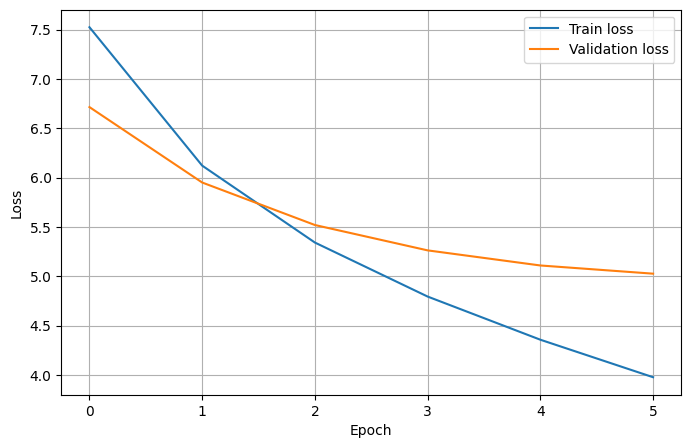

Epoch 6: train loss = 3.9766, val loss = 5.0260


('tokenizer/tokenizer_config.json',
 'tokenizer/special_tokens_map.json',
 'tokenizer/vocab.txt',
 'tokenizer/added_tokens.json',
 'tokenizer/tokenizer.json')

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
criterion = nn.NLLLoss(ignore_index=tokenizer.pad_token_id)
train_model(model, train_dataloader, eval_dataloader, optimizer, criterion, num_epochs=6, device=device, log_dir="runs/bert_summarization")
tokenizer.save_pretrained("tokenizer")

Видно, что имеется переобучение на поздних эпохах.

Сначала выберем примерчик для того, чтобы показать примеры генерации.

In [ ]:
example = eval_dataset[3]
input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(device)
attention_mask = torch.tensor(example["attention_mask"]).unsqueeze(0).to(device)
human_summary_ids = example["labels"]
text = tokenizer.decode(input_ids[0], skip_special_tokens=True, clean_up_tokenization_spaces=True)
human_summary = tokenizer.decode(human_summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)

Загружаем нашу модель и делаем генерацию summary.

In [16]:
model = BertSummarizer(bert_model_name=model_name)
model = model.to(device)

In [17]:
checkpoint = torch.load("best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
tokennizer = AutoTokenizer.from_pretrained("tokenizer")
model.to(device)
model.eval()

BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(36000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [23]:
summary = model.generate(input_ids, attention_mask, tokenizer, max_len=50)

In [24]:
print("Text:")
text

Text:


'оператив ##никам гу ##вд санкт - петербурга удалось задержать четвер ##ых участников организован ##нои преступ ##нои группы ( оп ##г ), которые в течение нескольких лет разными способами похи ##щали личныи транспорт граждан, сообщает пресс - служба гу ##вд. два участника банды ( одному 31 год, другому 28 лет ) были задержа ##ны мили ##ционера ##ми еще в июле прошлого года. однако двух их подел ##ь ##ников ( 31 год и 22 года ), которые все это время продолжали террори ##зировать питер ##ских авто ##вла ##дель ##цев, стражи порядка смогли поимать только спустя 11 месяцев. трое задержа ##нных зарегистри ##рованы в севернои столице, четвертыи – житель новгород ##скои области. есть ли еще участники этои оп ##г, пока неяс ##но. следствие считает, что первые кра ##жи преступник ##и совершили еще в 2008 году. только за один март они уг ##нали две машины « жи ##гули » — ваз - 211 ##50 и ваз - 211 ##40. в следующем году сообщ ##ники уг ##нали еще один отечествен ##ныи автомобиль газ - 330 ##23 

In [25]:
print("Our model summary")
summary

Our model summary


['в москве задержа ##н задержа ##н в москве задержа ##н сотрудник гибдд . в москве задержа ##н сотрудник гибдд и в москве за три года назад в москве за три года назад . в москве задержа ##н рублеи за три года задержа ##ны более чем в том числе и его']

In [26]:
print("Human summary")
human_summary

Human summary


'в санкт - петербурге задержа ##ны члены оп ##г, которые в течение нескольких лет террори ##зи ##ровали местных авто ##вла ##дель ##цев. под твер ##ью тем временем задержа ##н грузовик, в котором под видом баран ##ьи ##х шкур перевоз ##ились кра ##дены ##е машины.'

Теперь используем бейзлайн модель. Делаем тоже самое.

In [27]:
from transformers import AutoModelForSeq2SeqLM

baseline_model = AutoModelForSeq2SeqLM.from_pretrained("cointegrated/rut5-small")
baseline_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rut5-small")

baseline_model.to(device)
baseline_model.eval()

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


MT5ForConditionalGeneration(
  (shared): Embedding(20100, 512)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(20100, 512)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
            

Сначала еще нужно создать даталоадер с именно тем токенизатором для rut5

In [28]:
def preprocess_rut5(examples, use_padding=True):
    inputs = baseline_tokenizer(
        examples["text"],
        max_length=512,
        padding="max_length" if use_padding else False,
        truncation=True
    )

    targets = baseline_tokenizer(
        examples["summary"],
        max_length=128,
        padding="max_length" if use_padding else False,
        truncation=True
    )

    inputs["labels"] = targets["input_ids"]
    return inputs

In [29]:
rut5_dataset = dataset.map(preprocess_rut5, batched=False)
rut5_dataset.set_format("torch")

rut5_dataset = rut5_dataset.train_test_split(test_size=0.15)

rut5_eval_dataset = rut5_dataset["test"]

In [30]:
rut5_eval_dataloader = DataLoader(rut5_eval_dataset,  batch_size=8, shuffle=False)

In [ ]:
example = rut5_eval_dataset[3]
input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(device)
attention_mask = torch.tensor(example["attention_mask"]).unsqueeze(0).to(device)
human_summary_ids = example["labels"]
text = baseline_tokenizer.decode(input_ids[0], skip_special_tokens=True)
human_summary = baseline_tokenizer.decode(human_summary_ids, skip_special_tokens=True)

In [32]:
@torch.no_grad()
def generate_rut5_summary(text, model, tokenizer, device, max_len=50):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    summary_ids = model.generate(**inputs, max_length=max_len)

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

In [33]:
summary_rut5 = generate_rut5_summary(text, baseline_model, baseline_tokenizer, device)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Теперь выведем результаты.

In [34]:
print("Text:")
text

Text:


'В Екатеринбурге осуждены члены крупной банды, занимавшейся разбоями на трассах Свердловской области. Преступники похищали технику, перебивали номера агрегатов и продавали. Лидер группировки Севак Мартиросян приговорен к 12,5 года заключения. За этой бандой, похищавшей тяжелую технику и грузовики, оперативники охотились несколько лет. «Специализировались преступники на разбойных нападениях на водителей большегрузов и дорогостоящей автомобильной спецтехники. Действовала банда на автодорогах Свердловской и Челябинской областей, а реализовывала награбленное в Пермском крае», — сообщила пресс-секретарь МВД РФ по УрФО Юля Самсончик. Преступное сообщество создал бизнесмен Севак Мартиросян, в 90-е годы занимавшийся переоборудованием тяжелой техники. Тягачи, тракторы и грузовики в тот период он закупал у Министерства обороны по программе сокращения Вооруженных сил, переделывал их под гражданские нужды и легально реализовывал. Проблемы начались, когда иссяк поток дешевых армейских машин. «Тогда

In [35]:
print("ruT5-small summary")
summary_rut5

ruT5-small summary


'В Екатеринбурге осуждены сотрудники МВД, которые осуждены за незаконное производство, а останавливали работу по переделке автомобиля, а водитель, который и '

In [36]:
print("Human summary")
human_summary

Human summary


'На Урале осуждена банда лжегаишников, которые похищали грузовики, автотехнику и дорогие иномарки. Часть бандитов выбрала суд присяжных — и получила в итоге большие сроки, чем их подельники, выбравшие профессионального судью.'

И посчитаем те метрики.

In [37]:
@torch.no_grad()
def evaluate_rut5(model, dataloader, tokenizer, device, max_new_tokens=50):
    model.eval()
    predictions, references = [], []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        ref_texts = tokenizer.batch_decode(batch["labels"], skip_special_tokens=True)

        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens
        )

        pred_texts = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

        predictions.extend(pred_texts)
        references.extend(ref_texts)

    return compute_metrics(predictions, references)

In [38]:
metrics_custom = evaluation(model, eval_dataloader, tokenizer, device)
print("Custom model:")
metrics_custom

Custom model:


{'rouge1': np.float64(0.02954651873252806),
 'rouge2': np.float64(0.008331995385566813),
 'rougeL': np.float64(0.02865476791173116),
 'bleu': 0.05286447664524829,
 'bertscore_precision': 0.6811565557391581,
 'bertscore_recall': 0.6539391528586952,
 'bertscore_f1': 0.6669132435808376}

In [39]:
metrics_rut5 = evaluate_rut5(baseline_model, rut5_eval_dataloader, baseline_tokenizer, device)
print("ruT5-small:")
metrics_rut5

ruT5-small:


{'rouge1': np.float64(0.027864046586714222),
 'rouge2': np.float64(0.006973972334759507),
 'rougeL': np.float64(0.027674320941449213),
 'bleu': 0.007897666172469975,
 'bertscore_precision': 0.6630888974440688,
 'bertscore_recall': 0.6221613753424095,
 'bertscore_f1': 0.6417302195384621}

Ради интереса посмотрим сколько у нас параметров в модели и сколько параметров в модели ruT5-small.

In [40]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [41]:
print("BertSummarizer total params:", count_parameters(model))
print("BertSummarizer trainable params:", count_trainable_parameters(model))

BertSummarizer total params: 197376672
BertSummarizer trainable params: 197376672


In [42]:
print("ruT5-small total params:", count_parameters(baseline_model))
print("ruT5-small trainable params:", count_trainable_parameters(baseline_model))

ruT5-small total params: 64644480
ruT5-small trainable params: 64644480


**Итого**: обе модели делают суммаризацию не очень хорошо, у обоих присутствуют подходящие слова, и даже смысл какой-то имеется. По почти всем метрикам наша модель даже лучше, чем ruT5-small. Метрики, отвечающие за смысл (BertScore), у обоих моделей около 65%, то есть какой-то семантический смысл сохраняется. Еще в нашем токенайзере имеется проблема с окончаниями слов, которые отделяются ## и еще предложения итп не с большой буквы начинаются. Это все из-за особенностей BERT-токенизатора.

## Реализация менее жадных стратегий выбора следующего токена (4 балла)
Всегда ли выбор наиболее вероятного токена на каждом шаге – это лучшая стратегия для генерации текста?

<details>
    <summary>Спойлер</summary>
    <p>Нет</p>
</details>

**Сравнение стратегий для генерации текста:**

| Strategy | Description | Pros & Cons |
| --- | --- | --- |
| Greedy Search | Chooses the word with the highest probability as the next word in the sequence. | **Pros:** Simple and fast. <br><br/> **Cons:** Can lead to repetitive and incoherent text. |
| Sampling with Temperature | Introduces randomness in the word selection. A higher temperature leads to more randomness. | **Pros:** Allows exploration and diverse output. <br><br/> **Cons:** Higher temperatures can lead to nonsensical outputs. |
| Nucleus Sampling (Top-p Sampling) | Selects the next word from a truncated vocabulary, the "nucleus" of words <br/> that have a cumulative probability exceeding a pre-specified threshold (p). | **Pros:** Balances diversity and quality. <br><br/> **Cons:** Setting an optimal 'p' can be tricky. |
| Beam Search | Explores multiple hypotheses (sequences of words) at each step, and keeps <br/> the 'k' most likely, where 'k' is the beam width. | **Pros:** Produces more reliable results than greedy search. <br><br/> **Cons:** Can lack diversity and lead to generic responses. |
| Top-k Sampling | Randomly selects the next word from the top 'k' words with the highest probabilities. | **Pros:** Introduces randomness, increasing output diversity. <br><br/> **Cons:** Random selection can sometimes lead to less coherent outputs. |
| Length Normalization | Prevents the model from favoring shorter sequences by dividing the log probabilities <br/> by the sequence length raised to some power. | **Pros:** Makes longer and potentially more informative sequences more likely. <br><br/> **Cons:** Tuning the normalization factor can be difficult. |
| Stochastic Beam Search | Introduces randomness into the selection process of the 'k' hypotheses in beam search. | **Pros:** Increases diversity in the generated text. <br><br/> **Cons:** The trade-off between diversity and quality can be tricky to manage. |
| Decoding with Minimum Bayes Risk (MBR) | Chooses the hypothesis (out of many) that minimizes expected loss under a loss function. | **Pros:** Optimizes the output according to a specific loss function. <br><br/> **Cons:** Computationally more complex and requires a good loss function. |

Ссылки на докуметацию:
- [reference for `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [reference for `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- Huggingface [docs on generation strategies](https://huggingface.co/docs/transformers/generation_strategies)

**1. Реализуйте стратегию Top-k в методе `generate`** (1 балл).   

**2. Реализуйте стратегию Nucleus Sampling (Top-p) в методе `generate`** (1 балл)

**3. Реализуйте стратегию Beam Search** (2 балла)

Получилось ли улучшить генерацию?

Перепишем метод генерации из класса, придеться изменить класс. В методе разрешим делать выбор алгоритма.

In [43]:
# Класс модели для суммаризации на основе BERT с кастомным декодером
class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size

        # Эмбеддинги для токенов на входе в декодер
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        # Декодерные слои
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(hidden_size, num_heads, dropout) for _ in range(num_decoder_layers)]
        )

        # Выходной слой: предсказываем следующий токен
        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.log_softmax = nn.LogSoftmax(dim=-1)

        # Инициализируем все веса, кроме BERT
        self.embedding.apply(self._init_weights)
        for layer in self.decoder_layers:
            layer.apply(self._init_weights)
        self.fc_out.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            # Инициализация линейных слоёв (Xavier/Glorot)
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Инициализация эмбеддингов нормальным распределением
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    # Функция для создания маски для предотвращения заглядывания вперед в декодере
    def generate_square_subsequent_mask(self, T):
        mask = (torch.triu(torch.ones(T, T)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = (
            encoder_outputs.last_hidden_state
        )  # Выходы BERT для использования в декодере

        # Эмбеддинги для входных токенов декодера
        x = self.embedding(decoder_input_ids)

        # Генирируем масиву для предотвращения заглядывания вперед в декодере
        tgt_mask = self.generate_square_subsequent_mask(x.size(1)).to(x.device)

        # Проходимся по всем слоям в декодере
        for layer in self.decoder_layers:
            x = layer(x, memory, tgt_mask=tgt_mask)

        # Далее линейный словй и возвращаем LogSoftmax
        output = self.fc_out(x)
        return self.log_softmax(output)

    def generate(self, input_ids, attention_mask, tokenizer, max_len=50, strategy="greedy", top_k=50, top_p=0.9, num_beams=3):
        self.eval()
        device = input_ids.device
        batch_size = input_ids.size(0)

        with torch.no_grad():
            encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            memory = encoder_outputs.last_hidden_state

            decoder_input_ids = torch.full((batch_size, 1), tokenizer.cls_token_id, dtype=torch.long, device=device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

            if strategy == "beam":
                beams = [[(decoder_input_ids[i:i+1].clone(), 0.0)] for i in range(batch_size)]

                for step in range(max_len):
                    all_finished = True

                    for i in range(batch_size):
                        if finished[i]:
                            continue
                        all_finished = False
                        current_beams = beams[i]
                        all_candidates = []

                        for seq, score in current_beams:
                            x = self.embedding(seq)
                            tgt_mask = self.generate_square_subsequent_mask(x.size(1)).to(device)
                            for layer in self.decoder_layers:
                                x = layer(x, memory[i:i+1].expand(x.size(0), -1, -1), tgt_mask)
                            logits = self.fc_out(x)[:, -1, :]
                            log_probs = self.log_softmax(logits)
                            top_log_probs, top_ids = torch.topk(log_probs, num_beams, dim=-1)

                            for j in range(num_beams):
                                candidate_seq = torch.cat([seq, top_ids[:, j:j+1]], dim=1)
                                candidate_score = score + top_log_probs[:, j].item()
                                all_candidates.append((candidate_seq, candidate_score))

                        all_candidates.sort(key=lambda x: x[1], reverse=True)
                        beams[i] = all_candidates[:num_beams]

                        all_beams_finished = all(seq[0, -1].item() == tokenizer.sep_token_id for seq, _ in beams[i])
                        if all_beams_finished:
                            finished[i] = True

                    if all_finished or finished.all():
                        break

                decoder_input_ids = torch.cat([beams[i][0][0] for i in range(batch_size)], dim=0)

            else:
                for step in range(max_len):
                    if finished.all():
                        break

                    x = self.embedding(decoder_input_ids)
                    tgt_mask = self.generate_square_subsequent_mask(x.size(1)).to(device)
                    for layer in self.decoder_layers:
                        x = layer(x, memory, tgt_mask)
                    logits = self.fc_out(x)[:, -1, :]

                    if strategy == "greedy":
                        next_token = self.log_softmax(logits).argmax(dim=-1, keepdim=True)
                    elif strategy == "top_k":
                        top_k_current = min(top_k, logits.size(-1))
                        probs = torch.softmax(logits, dim=-1)
                        top_probs, top_indices = torch.topk(probs, top_k_current, dim=-1)
                        next_token = top_indices.gather(-1, torch.multinomial(top_probs, 1))
                    elif strategy == "nucleus":
                        probs = torch.softmax(logits, dim=-1)
                        sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
                        mask = cumulative_probs > top_p
                        mask[:, 1:] = mask[:, :-1].clone()
                        mask[:, 0] = False
                        sorted_probs[mask] = 0.0
                        sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
                        next_token = sorted_indices.gather(-1, torch.multinomial(sorted_probs, 1))


                    finished |= (next_token.squeeze(-1) == tokenizer.sep_token_id)
                    decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=1)

        decoded_texts = []
        for seq in decoder_input_ids.tolist():
            sep_indices = [i for i, token_id in enumerate(seq) if token_id == tokenizer.sep_token_id]
            if sep_indices:
                seq = seq[:sep_indices[0]]
            clean_tokens = [t for t in seq if t not in (tokenizer.cls_token_id, tokenizer.pad_token_id)]
            decoded_texts.append(tokenizer.decode(clean_tokens, skip_special_tokens=True))

        return decoded_texts

In [44]:
model = BertSummarizer(bert_model_name=model_name)
model = model.to(device)
checkpoint = torch.load("best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
tokennizer = AutoTokenizer.from_pretrained("tokenizer")
model.to(device)
model.eval()

BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(36000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [45]:
example = eval_dataset[5]
input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(device)
attention_mask = torch.tensor(example["attention_mask"]).unsqueeze(0).to(device)
human_summary_ids = example["labels"]
text = tokenizer.decode(input_ids[0], skip_special_tokens=True, clean_up_tokenization_spaces=True)
human_summary = tokenizer.decode(human_summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)

/tmp/ipython-input-1197561694.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(device)
/tmp/ipython-input-1197561694.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(example["attention_mask"]).unsqueeze(0).to(device)


In [46]:
summary_greedy = model.generate(input_ids, attention_mask, tokenizer, max_len=50, strategy="greedy")
summary_beam = model.generate(input_ids, attention_mask, tokenizer, max_len=50, strategy="beam")
summary_nucleus = model.generate(input_ids, attention_mask, tokenizer, max_len=50, strategy="nucleus")
summary_top_k = model.generate(input_ids, attention_mask, tokenizer, max_len=50, strategy="top_k")

In [47]:
print("Text:")
text

Text:


'перечень нет ##я ##жки ##х преступлении, по которым будет запре ##щена мера пресе ##чения заключение под страж ##у, может быть расшир ##ен. президент дмитрии медведев в ходе рабочеи встречи попросил министра юсти ##ции александра коно ##вало ##ва проду ##мат ##ь этот вопрос. « мы приняли решения по экономи ##ческим преступления ##м, но есть масса других нет ##я ##жки ##х преступлении, где точно никакого резона отправлять человека за решетку нет. об этом тоже нужно думать », — сказал глава государства. « думаю, что если бы мин ##ю ##ст этим вопросом занялся, то был бы толк », — заключил медведев. коно ##вало ##в отметил, что уже после того, как стали перест ##раи ##ваться на сокращение досу ##деб ##ных арестов, происходили « прис ##кор ##б ##ные эпизод ##ы, в том числе смерть людеи в след ##ственных изоля ##торах ». он добавил, что такие случаи не един ##ич ##ны и за 2009 году в си ##зо умерли 23 ##3 человека. « известность получают только самые резона ##нс ##ные преступления или, скаж

In [48]:
print("Greedy summary")
summary_greedy

Greedy summary


['президент дмитрии медведев заявил , что в том числе и его мнению , что в том числе и не будет , а также не будет . по мнению экспертов , что они будут .']

In [49]:
print("Beam search summary")
summary_beam

Beam search summary


['президент дмитрии медведев заявил , что в том числе по делу ю ##кос ##нове ##нно ##сти . по мнению экспертов , в том числе и его мнению экспертов , что он не будет . это уже ##сто ##чить наказание , чтобы не будет .']

In [50]:
print("Nucleus summary")
summary_nucleus

Nucleus summary


['президент дмитрии медведев заявил о крат ##на бои ##ко информацию о противодеи ##дал ##лы ##ла приговор ##е , что россииские в мошен ##ни ##честве обвин ##ении и арест ##а заяв ##ляют , что уже спасти несколько человек . , но к проект требовать остаются в следующем году он не лиш']

In [51]:
print("Top k summary")
summary_top_k

Top k summary


['президент дмитрии медведев намерен ##а чиновников в незакон ##ном чт ##ении дела о корруп ##ции в уголов ##ном заседании , считает глава мин ##при ##род ##ы . он также сообщил в закон ##ную операцию . в частности , что он не стоит , а также пока рано , считает как']

In [52]:
print("Human summary")
human_summary

Human summary


'президент за дальнеишее расширение пере ##ч ##ня преступлении, по которым будет запре ##щена мера пресе ##чения в виде заключения под страж ##у. по мнению мин ##ю ##ста, в си ##зо надо отправлять обвиня ##емых по тяж ##ким и особо тяж ##ким статья ##м, а также если личность подозре ##ваемого слишком оди ##оз ##на.'

In [53]:
@torch.no_grad()
def evaluation(model, dataloader, tokenizer, device, max_len=50, strategy="greedy", top_k=50, top_p=0.9, num_beams=3):
    model.eval()

    predictions = []
    references = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        ref_texts = tokenizer.batch_decode(batch["labels"], skip_special_tokens=True)

        pred_texts = model.generate(input_ids=input_ids, attention_mask=attention_mask, tokenizer=tokenizer,
                                    max_len=max_len, strategy=strategy, top_k=top_k, top_p=top_p, num_beams=num_beams)

        predictions.extend(pred_texts)
        references.extend(ref_texts)

    metrics = compute_metrics(predictions, references)
    return metrics

In [54]:
metrics_custom = evaluation(model, eval_dataloader, tokenizer, device, strategy="greedy")
print("model greedy:")
metrics_custom

model greedy:


{'rouge1': np.float64(0.02954651873252806),
 'rouge2': np.float64(0.008331995385566813),
 'rougeL': np.float64(0.02865476791173116),
 'bleu': 0.05286447664524829,
 'bertscore_precision': 0.6811565557391581,
 'bertscore_recall': 0.6539391528586952,
 'bertscore_f1': 0.6669132435808376}

In [56]:
metrics_custom = evaluation(model, eval_dataloader, tokenizer, device, strategy="nucleus")
print("model nucleus:")
metrics_custom

model nucleus:


{'rouge1': np.float64(0.01469797563277575),
 'rouge2': np.float64(0.0014628431173620677),
 'rougeL': np.float64(0.014149683428046535),
 'bleu': 0.05305960482633727,
 'bertscore_precision': 0.7061895542607015,
 'bertscore_recall': 0.6947383082121523,
 'bertscore_f1': 0.7002998414957141}

In [57]:
metrics_custom = evaluation(model, eval_dataloader, tokenizer, device, strategy="top_k")
print("model top_k:")
metrics_custom

model top_k:


{'rouge1': np.float64(0.026214412533541696),
 'rouge2': np.float64(0.005390261763689752),
 'rougeL': np.float64(0.025308615202213017),
 'bleu': 0.058437348193697364,
 'bertscore_precision': 0.7056635368843468,
 'bertscore_recall': 0.6928463990504123,
 'bertscore_f1': 0.6990562883740611}

В итоге, довольно тяжело глазами определить уровень генерации он везде не очень, а вот по метрикам выигрывает top_k.

## Бонус (1 балл)

Что требуется сделать:

- от имеющейся модели "откусить" только декодерную часть
- написать цикл обучения (скорее поправить имеющийся) и дообучить декодер
- посмотреть качество генерации по метрикам и "глазами"
- ответить на вопрос "Дает ли применение Encoder-Decoder архитектуры значительный буст в качестве генерации?" с пруфами